Imports

In [10]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sksurv.metrics import cumulative_dynamic_auc
from sksurv.datasets import load_flchain

class Config:
    dataset_name = "METABRIC"  
    seed = 42
    test_size = 0.2
    lr = 1e-3
    final_lr = 1e-4
    k_bins = 100  
    target_k = 15 
    l_lambda_fixed = 0 
    tau = 0.1
    bisection_enabled = True 
    bisection_steps = 10
    final_epochs = 200
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cfg = Config()
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)

architecture

### Data fetching function

In [11]:
def prepare_metabric(test_size=0.2, random_state=42):
    df_x = pd.read_csv("../data/metabric/metabric_df.csv")
    df_y = pd.read_csv("../data/metabric/label.csv")

    x_cols = df_x.drop(columns=[c for c in df_x.columns if 'Genefu' in c])

    feature_names = x_cols.columns.tolist()
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x_cols)

    t = df_y['event_time'].values
    e = df_y['label'].values

    return (
        train_test_split(
            x_scaled,
            t,
            e,
            test_size=test_size,
            random_state=random_state
        ),
        feature_names,
        scaler
    )


def prepare_flchain(test_size=0.2, random_state=42):
    data_x, data_y = load_flchain()
    data_x = pd.get_dummies(data_x, drop_first=True)
    data_x = data_x.fillna(data_x.mean())
    feature_names = data_x.columns.tolist()
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(data_x)

    t = data_y['futime']
    e = data_y['death'].astype(int)

    return (
        train_test_split(
            x_scaled,
            t,
            e,
            test_size=test_size,
            random_state=random_state
        ),
        feature_names,
        scaler
    )


def prepare_dataset(dataset_name, test_size=0.2, random_state=cfg.seed):
    dataset_name = dataset_name.lower()

    if dataset_name == "metabric":
        return prepare_metabric(
            test_size=test_size,
            random_state=random_state
        )

    elif dataset_name == "flchain":
        return prepare_flchain(
            test_size=test_size,
            random_state=random_state
        )

    else:
        raise ValueError(
            f"Unknown dataset: {dataset_name}. "
            f"Available datasets: ['metabric', 'flchain']"
        )

### Model architecture

In [12]:
class SmoothStepGate(nn.Module):
    def __init__(self, size):
        super().__init__()
        self.mu = nn.Parameter(torch.randn(size) * 0.01) 
        
    def forward(self):
        x = torch.clamp(self.mu + 0.5, 0, 1)
        return 3 * x**2 - 2 * x**3

class ShapeFunction(nn.Module):
    def __init__(self, input_dim, K):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, K)
        )
    def forward(self, x): 
        return self.net(x)


class DySModel(nn.Module):
    def __init__(self, num_features, K):
        super().__init__()
        self.K = K
        self.num_features = num_features
        
        self.main_effects = nn.ModuleList([ShapeFunction(1, K) for _ in range(num_features)])
        self.main_gates = SmoothStepGate(num_features)
        
        self.interaction_effects = nn.ModuleDict()
        self.interaction_gates = None
        
        self.intercept = nn.Parameter(torch.zeros(1, K))

    def forward(self, x):
        s_m = self.main_gates()
        logits = self.intercept.expand(x.shape[0], -1).clone()
        
        for i in range(self.num_features):
            logits += self.main_effects[i](x[:, i:i+1]) * s_m[i]
            

        if self.interaction_gates is not None:
            s_i = self.interaction_gates()
            for idx, (key, layer) in enumerate(self.interaction_effects.items()):
                f1, f2 = map(int, key.split('_'))
                feat_combined = x[:, [f1, f2]]
                logits += layer(feat_combined) * s_i[idx]
                
        pmf = torch.softmax(logits, dim=1)
        return 1 - torch.cumsum(pmf, dim=1)




### Loss function

In [13]:
def omega(x):
    x = torch.clamp(x, 1e-7, 1-1e-7)
    return -(x * torch.log(x) + (1 - x) * torch.log(1 - x))


def evaluate_auc(model, x_test, t_train, e_train, t_test, e_test, eval_times):
    model.eval()
    with torch.no_grad():
        x_te = torch.tensor(x_test, dtype=torch.float32).to(cfg.device)
        surv_pred = model(x_te).cpu().numpy()
        risk_scores = 1 - surv_pred[:, len(eval_times)//2]
        y_train = np.array([(bool(e), t) for e, t in zip(e_train, t_train)], dtype=[('event', 'bool'), ('time', 'float')])
        y_test = np.array([(bool(e), t) for e, t in zip(e_test, t_test)], dtype=[('event', 'bool'), ('time', 'float')])
        times = np.percentile(t_test[e_test == 1], [25, 50, 75])
        auc, mean_auc = cumulative_dynamic_auc(y_train, y_test, risk_scores, times)
        return mean_auc


def compute_dys_loss(surv, t, e, eval_times, model, l_lambda, tau=0.1, is_stage2=False):
    t_eval = torch.tensor(eval_times, device=surv.device).float().unsqueeze(0)
    t_actual = t.unsqueeze(1)
    
    # RPS Loss 
    mask_before = (t_eval < t_actual).float()
    mask_after = (t_eval >= t_actual).float()
    l_rps = ((1 - surv).pow(2) * mask_before).sum(dim=1) + \
            (surv.pow(2) * mask_after * e.unsqueeze(1)).sum(dim=1)
    
    # Sparsity regularizer L_SS 
    s_m = model.main_gates()
    l_ss = l_lambda * s_m.sum()
    
    # Entropy regularizer L_E 
    l_e = tau * omega(s_m).sum()
    
    if is_stage2 and model.interaction_gates is not None:
        s_i = model.interaction_gates()
        l_ss += l_lambda * 0.5 * s_i.sum() 
        l_e += tau * omega(s_i).sum()

    return l_rps.mean() + l_ss + l_e


### Model training function 

In [14]:
def train_dys(model, x_train, t_train, e_train, x_test, t_test, e_test, eval_times, l_lambda, use_interactions=False):
    print("--- Stage 1: Training Main Effects ---")
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(100):
        model.train()
        optimizer.zero_grad()
        surv = model(x_train)
        loss = compute_dys_loss(surv, t_train, e_train, eval_times, model, l_lambda)
        loss.backward()
        optimizer.step()
    
    auc_stage1 = evaluate_auc(model, x_test, t_train, e_train, t_test, e_test, eval_times)
    # print(f"AUC after Stage 1 (Main Effects only): {auc_stage1:.4f}")

    if not use_interactions:
        print("Configuration: Stage 2 skipped.")
        return model

    with torch.no_grad():
        active_features = torch.where(model.main_gates() > 1e-3)[0].tolist()
    
    print(f"Active features for interactions: {len(active_features)} features selected")
    
    interactions = []
    for i in range(len(active_features)):
        for j in range(i + 1, len(active_features)):
            f1, f2 = active_features[i], active_features[j]
            model.interaction_effects[f"{f1}_{f2}"] = ShapeFunction(2, model.K).to(x_train.device)
            interactions.append(f"{f1}_{f2}")
    
    if interactions:
        model.interaction_gates = SmoothStepGate(len(interactions)).to(x_train.device)
        for param in model.main_effects.parameters():
            param.requires_grad = False
        
        print(f"--- Stage 2: Training {len(interactions)} interactions ---")
        optimizer_i = torch.optim.Adam(list(model.interaction_effects.parameters()) + 
                                       list(model.interaction_gates.parameters()), lr=1e-3)
        for epoch in range(100):
            model.train()
            optimizer_i.zero_grad()
            surv = model(x_train)
            loss = compute_dys_loss(surv, t_train, e_train, eval_times, model, l_lambda, is_stage2=True)
            loss.backward()
            optimizer_i.step()

        auc_stage2 = evaluate_auc(model, x_test, t_train, e_train, t_test, e_test, eval_times)
        print(f"AUC after Stage 2 (Main Effects + Interactions): {auc_stage2:.4f}")
        print(f"Improvement from interactions: {auc_stage2 - auc_stage1:.4f}")
    else:
        print("No interactions created (too few active features).")

    return model

### Dataset Prepare Function

In [15]:
(
    x_train,
    x_test,
    t_train,
    t_test,
    e_train,
    e_test
), feature_names, scaler = prepare_dataset(cfg.dataset_name)


x_t = torch.tensor(x_train, dtype=torch.float32).to(cfg.device)
t_t = torch.tensor(t_train, dtype=torch.float32).to(cfg.device)
e_t = torch.tensor(e_train, dtype=torch.float32).to(cfg.device)

eval_times = np.linspace(0, t_train.max(), cfg.k_bins)

### Model Training and eval

In [16]:
model = DySModel(len(feature_names), cfg.k_bins).to(cfg.device)


model = train_dys(
    model, 
    x_t, t_t, e_t,       
    x_test, t_test, e_test, 
    eval_times,        
    l_lambda=0.05, 
    use_interactions=False
)


model.eval()
with torch.no_grad():
    total_offset = torch.zeros(1, cfg.k_bins).to(cfg.device)
    for i in range(model.num_features):
        feature_slice = x_t[:, i:i+1]
        mean_val = model.main_effects[i](feature_slice).mean(dim=0)
        
        total_offset += mean_val * model.main_gates()[i]
        
    model.intercept.data += total_offset

auc = evaluate_auc(model, x_test, t_train, e_train, t_test, e_test, eval_times)
print(f"Final Model AUC: {auc:.4f}")

--- Stage 1: Training Main Effects ---
Configuration: Stage 2 skipped.
Final Model AUC: 0.7257


### Plot Functions

In [17]:
def plot_impact_plots(model, x_train, feature_names, eval_times, scaler, feature_to_plot):
    if feature_to_plot not in feature_names:
        print(f"Feature {feature_to_plot} not found.")
        return

    idx = feature_names.index(feature_to_plot)
    model.eval()
    

    x_min, x_max = x_train[:, idx].min().item(), x_train[:, idx].max().item()
    x_range = torch.linspace(x_min, x_max, 100).view(-1, 1).to(x_train.device)
    
    with torch.no_grad():

        impacts = model.main_effects[idx](x_range).cpu().numpy()
        
        train_feat = x_train[:, idx:idx+1]
        mean_offset = model.main_effects[idx](train_feat).mean(dim=0).cpu().numpy()
        impacts -= mean_offset

    t1_idx = np.abs(eval_times - 365).argmin()
    t3_idx = np.abs(eval_times - 1095).argmin()
    x_real = (x_range.cpu().numpy().flatten() * np.sqrt(scaler.var_[idx])) + scaler.mean_[idx]

    plt.figure(figsize=(8, 5))
    plt.plot(x_real, impacts[:, t1_idx], label=f"t = {int(eval_times[t1_idx])} days (~1 Year)", color="blue", lw=2)
    plt.plot(x_real, impacts[:, t3_idx], label=f"t = {int(eval_times[t3_idx])} days (~3 Years)", color="red", linestyle="--", lw=2)
    
    plt.axhline(0, color='black', lw=0.8, ls='-') 
    plt.title(f"DyS Impact Plot: {feature_to_plot}")
    plt.xlabel(f"Actual Value: {feature_to_plot}")
    plt.ylabel("Logit Impact (Centered)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_feature_importance(model, x_train, feature_names):
    model.eval()
    with torch.no_grad():
        importances = []
        gates = model.main_gates().cpu().numpy()
        
        for i in range(model.num_features):
            feat_input = x_train[:, i:i+1]
  
            impact = model.main_effects[i](feat_input).abs().mean().item()
            importances.append(impact * gates[i])
            
    indices = np.argsort(importances)[::-1][:15] 
    
    plt.figure(figsize=(8, 6))

    y_vals = np.array(feature_names)[indices]
    x_vals = np.array(importances)[indices]
    
    sns.barplot(
        x=x_vals, 
        y=y_vals, 
        hue=y_vals, 
        palette="viridis", 
        legend=False
    )
    
    plt.title("Global Feature Importances (Averaged across times)")
    plt.xlabel("Importance Score")
    plt.show()



### Plots

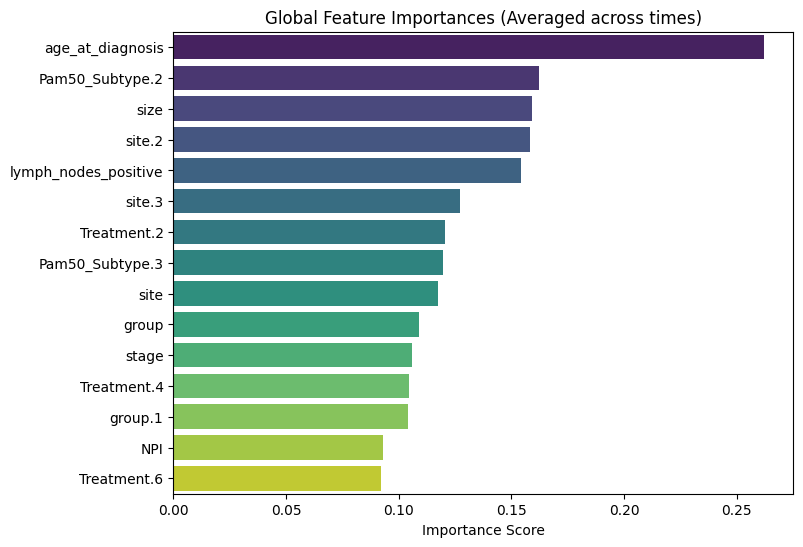

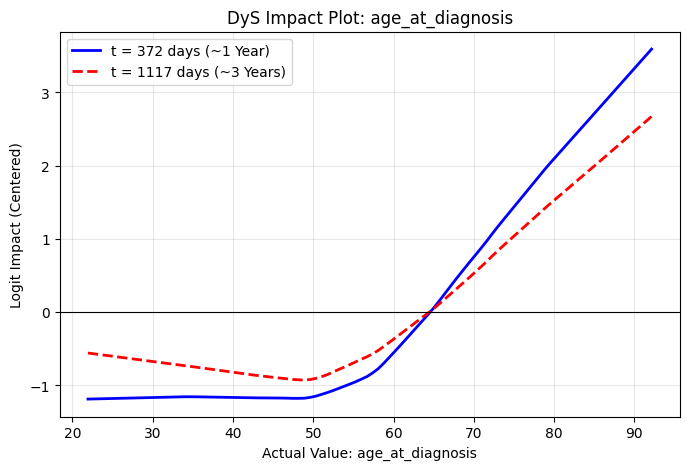

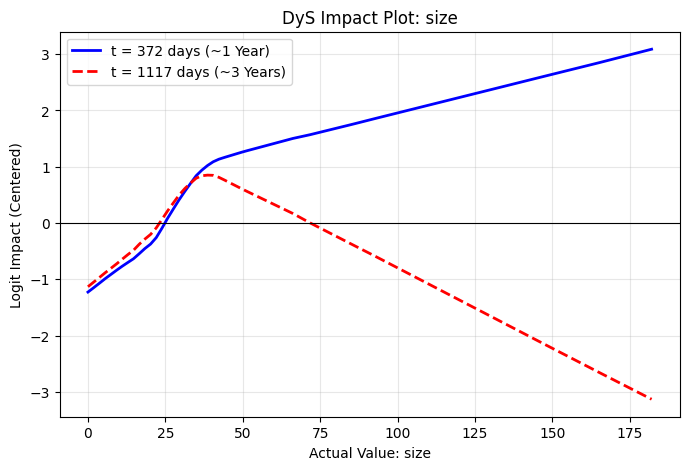

In [18]:
if cfg.dataset_name == "FLCHAIN":
    plot_feature_importance(model, x_t, feature_names)
    plot_impact_plots(model, x_t, feature_names, eval_times, scaler, "age")
elif cfg.dataset_name == "METABRIC":
    plot_feature_importance(model, x_t, feature_names)
    plot_impact_plots(model, x_t, feature_names, eval_times, scaler, "age_at_diagnosis")
    plot_impact_plots(model, x_t, feature_names, eval_times, scaler, "size")